## EDA

In [1]:
import torch
import torch.nn as nn

#-------------------------- PATCH EMBEDDING--------------------------#
# It converts the input image into a sequence of patch tokens.

class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=4, in_chans=3, embed_dim=96, norm_layer=None):
        super().__init__()
        
        self.img_size = (img_size, img_size)
        self.patch_size = (patch_size, patch_size)
        self.num_patches = (img_size // patch_size) ** 2  # 56*56 = 3136
        self.embed_dim = embed_dim
        
        # one conv does patch splitting + embedding in one shot
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        
        # optional normalization
        self.norm = norm_layer(embed_dim) if norm_layer else None

    def forward(self, x):
        B, C, H, W = x.shape
        
        x = self.proj(x)        # (B, 96, 56, 56)
        x = x.flatten(2)        # (B, 96, 3136)
        x = x.transpose(1, 2)  # (B, 3136, 96)
        
        if self.norm:
            x = self.norm(x)
            
        return x

# Split the feature map into non-overlapping windows.
# Swin Transformer performs self-attention inside small windows, not across the whole image.
def window_partition(x, window_size):
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows

# Reconstruct the original feature map from the windows.
# This is used after window attention.
def window_reverse(windows, window_size, H, W):
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    return x

class WindowAttention(nn.Module):
    def __init__(self, dim, window_size, num_heads, qkv_bias=True, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.dim = dim
        self.window_size = window_size  # 7
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        # relative position bias table
        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2 * window_size - 1) * (2 * window_size - 1), num_heads))
        nn.init.trunc_normal_(self.relative_position_bias_table, std=.02)

        # relative position index
        coords_h = torch.arange(self.window_size)
        coords_w = torch.arange(self.window_size)
        coords = torch.stack(torch.meshgrid([coords_h, coords_w], indexing='ij'))  # 2, 7, 7
        coords_flatten = torch.flatten(coords, 1)  # 2, 49

        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]  # 2, 49, 49
        relative_coords = relative_coords.permute(1, 2, 0).contiguous()  # 49, 49, 2
        relative_coords[:, :, 0] += self.window_size - 1
        relative_coords[:, :, 1] += self.window_size - 1
        relative_coords[:, :, 0] *= 2 * self.window_size - 1
        relative_position_index = relative_coords.sum(-1)  # 49, 49
        self.register_buffer("relative_position_index", relative_position_index)

        self.qkv = nn.Linear(dim, dim * 3, qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x, mask=None):
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        q = q * self.scale
        attn = (q @ k.transpose(-2, -1))

        # add relative position bias
        relative_position_bias = self.relative_position_bias_table[
            self.relative_position_index.view(-1)].view(
            self.window_size * self.window_size,
            self.window_size * self.window_size, -1)
        relative_position_bias = relative_position_bias.permute(2, 0, 1).contiguous()
        attn = attn + relative_position_bias.unsqueeze(0)

        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(B_ // nW, nW, self.num_heads, N, N) + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)

        attn = self.softmax(attn)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

from timm.layers import DropPath
class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, drop=0.):
        super().__init__()
        hidden_features = hidden_features or in_features
        out_features = out_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class SwinTransformerBlock(nn.Module):
    def __init__(self, dim, input_resolution, num_heads, window_size=7,
                 shift_size=0, mlp_ratio=4., qkv_bias=True,
                 drop=0., attn_drop=0., drop_path=0.):
        super().__init__()
        self.dim = dim
        self.input_resolution = input_resolution
        self.num_heads = num_heads
        self.window_size = window_size
        self.shift_size = shift_size

        # if window is larger than input, no shifting needed
        if min(self.input_resolution) <= self.window_size:
            self.shift_size = 0
            self.window_size = min(self.input_resolution)

        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(
            dim, window_size=self.window_size,
            num_heads=num_heads,
            qkv_bias=qkv_bias,
            attn_drop=attn_drop,
            proj_drop=drop)

        self.drop_path = nn.Identity() if drop_path == 0. else DropPath(drop_path)
        self.norm2 = nn.LayerNorm(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden_dim, drop=drop)

        # attention mask for shifted windows
        if self.shift_size > 0:
            H, W = self.input_resolution
            img_mask = torch.zeros((1, H, W, 1))
            h_slices = (slice(0, -self.window_size),
                        slice(-self.window_size, -self.shift_size),
                        slice(-self.shift_size, None))
            w_slices = (slice(0, -self.window_size),
                        slice(-self.window_size, -self.shift_size),
                        slice(-self.shift_size, None))
            cnt = 0
            for h in h_slices:
                for w in w_slices:
                    img_mask[:, h, w, :] = cnt
                    cnt += 1
            mask_windows = window_partition(img_mask, self.window_size)
            mask_windows = mask_windows.view(-1, self.window_size * self.window_size)
            attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
            attn_mask = attn_mask.masked_fill(attn_mask != 0, -100.0).masked_fill(attn_mask == 0, 0.0)
        else:
            attn_mask = None

        self.register_buffer("attn_mask", attn_mask)

    def forward(self, x, H, W):
        B, L, C = x.shape

        shortcut = x
        x = self.norm1(x)
        x = x.view(B, H, W, C)

        # cyclic shift
        if self.shift_size > 0:
            shifted_x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2))
        else:
            shifted_x = x

        # partition windows
        x_windows = window_partition(shifted_x, self.window_size)
        x_windows = x_windows.view(-1, self.window_size * self.window_size, C)

        # attention
        attn_windows = self.attn(x_windows, mask=self.attn_mask)

        # merge windows
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        shifted_x = window_reverse(attn_windows, self.window_size, H, W)

        # reverse cyclic shift
        if self.shift_size > 0:
            x = torch.roll(shifted_x, shifts=(self.shift_size, self.shift_size), dims=(1, 2))
        else:
            x = shifted_x

        x = x.view(B, H * W, C)
        x = shortcut + self.drop_path(x)

        # MLP
        x = x + self.drop_path(self.mlp(self.norm2(x)))

        return x

class PatchMerging(nn.Module):
    def __init__(self, input_resolution, dim, norm_layer=nn.LayerNorm):
        super().__init__()
        self.input_resolution = input_resolution
        self.dim = dim
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = norm_layer(4 * dim)

    def forward(self, x, H, W):
        B, L, C = x.shape
        x = x.view(B, H, W, C)

        # grab 2x2 neighboring patches
        x0 = x[:, 0::2, 0::2, :]  # top left
        x1 = x[:, 1::2, 0::2, :]  # bottom left
        x2 = x[:, 0::2, 1::2, :]  # top right
        x3 = x[:, 1::2, 1::2, :]  # bottom right

        x = torch.cat([x0, x1, x2, x3], -1)  # B, H/2, W/2, 4C
        x = x.view(B, -1, 4 * C)

        x = self.norm(x)
        x = self.reduction(x)  # B, H/2*W/2, 2C

        return x

class BasicLayer(nn.Module):
    def __init__(self, dim, input_resolution, depth, num_heads, window_size,
                 mlp_ratio=4., qkv_bias=True, drop=0., attn_drop=0.,
                 drop_path=0., downsample=None):
        super().__init__()
        self.dim = dim
        self.input_resolution = input_resolution
        self.depth = depth

        # stack multiple SwinTransformerBlocks
        self.blocks = nn.ModuleList([
            SwinTransformerBlock(
                dim=dim,
                input_resolution=input_resolution,
                num_heads=num_heads,
                window_size=window_size,
                shift_size=0 if (i % 2 == 0) else window_size // 2,  # alternate W-MSA and SW-MSA
                mlp_ratio=mlp_ratio,
                qkv_bias=qkv_bias,
                drop=drop,
                attn_drop=attn_drop,
                drop_path=drop_path[i] if isinstance(drop_path, list) else drop_path
            )
            for i in range(depth)
        ])

        # downsampling at end of stage
        self.downsample = downsample

    def forward(self, x, H, W):
        for blk in self.blocks:
            x = blk(x, H, W)

        if self.downsample is not None:
            x = self.downsample(x, H, W)
            H, W = H // 2, W // 2

        return x, H, W

class SwinTransformer(nn.Module):
    def __init__(self, img_size=224, patch_size=4, in_chans=3, num_classes=7,
                 embed_dim=96, depths=[2, 2, 18, 2], num_heads=[3, 6, 12, 24],
                 window_size=7, mlp_ratio=4., qkv_bias=True,
                 drop_rate=0., attn_drop_rate=0., drop_path_rate=0.1):
        super().__init__()
        self.num_classes = num_classes
        self.num_layers = len(depths)
        self.embed_dim = embed_dim
        self.mlp_ratio = mlp_ratio

        # patch embedding
        self.patch_embed = PatchEmbed(
            img_size=img_size, patch_size=patch_size,
            in_chans=in_chans, embed_dim=embed_dim)

        self.pos_drop = nn.Dropout(p=drop_rate)

        # stochastic depth decay rule
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))]

        # build 4 stages
        self.layers = nn.ModuleList()
        for i_layer in range(self.num_layers):
            dim = int(embed_dim * 2 ** i_layer)
            input_resolution = (
                img_size // patch_size // (2 ** i_layer),
                img_size // patch_size // (2 ** i_layer)
            )
            depth = depths[i_layer]
            downsample = PatchMerging(
                input_resolution=input_resolution,
                dim=dim
            ) if i_layer < self.num_layers - 1 else None

            layer = BasicLayer(
                dim=dim,
                input_resolution=input_resolution,
                depth=depth,
                num_heads=num_heads[i_layer],
                window_size=window_size,
                mlp_ratio=mlp_ratio,
                qkv_bias=qkv_bias,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[sum(depths[:i_layer]):sum(depths[:i_layer+1])],
                downsample=downsample
            )
            self.layers.append(layer)

        # final norm + classifier head
        self.norm = nn.LayerNorm(int(embed_dim * 2 ** (self.num_layers - 1)))
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Linear(int(embed_dim * 2 ** (self.num_layers - 1)), num_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # patch embedding
        x = self.patch_embed(x)
        x = self.pos_drop(x)

        H, W = 56, 56  # initial resolution after patch embed

        # pass through 4 stages
        for layer in self.layers:
            x, H, W = layer(x, H, W)

        x = self.norm(x)
        x = self.avgpool(x.transpose(1, 2))
        x = torch.flatten(x, 1)
        x = self.head(x)

        return x

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# check dataset
df = pd.read_csv('/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')
print(df.shape)
print(df.head())

(10015, 7)
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


In [3]:
print(df['dx'].value_counts())
print()
print(df['dx'].value_counts(normalize=True) * 100)

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

dx
nv       66.949576
mel      11.113330
bkl      10.973540
bcc       5.132302
akiec     3.265102
vasc      1.417873
df        1.148278
Name: proportion, dtype: float64


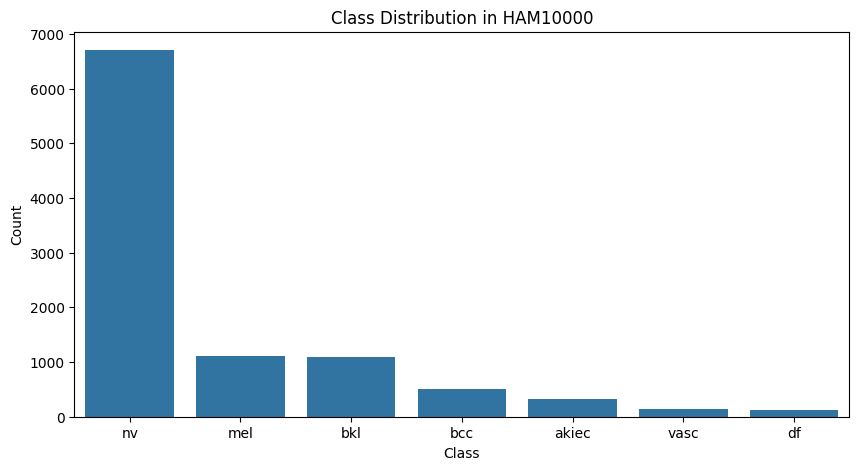

In [4]:
plt.figure(figsize=(10, 5))
sns.barplot(x=df['dx'].value_counts().index, 
            y=df['dx'].value_counts().values)
plt.title('Class Distribution in HAM10000')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [5]:
print(df.isnull().sum())

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64


In [6]:
import os
from PIL import Image

# find image directories
img_dir1 = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1'
img_dir2 = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2'

# check one image from each part
sample1 = os.listdir(img_dir1)[0]
sample2 = os.listdir(img_dir2)[0]

img1 = Image.open(os.path.join(img_dir1, sample1))
img2 = Image.open(os.path.join(img_dir2, sample2))

print(f"Part 1 sample size: {img1.size}")
print(f"Part 2 sample size: {img2.size}")

Part 1 sample size: (600, 450)
Part 2 sample size: (600, 450)


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

classes = df['dx'].unique()

for i, cls in enumerate(classes):
    # get a sample image from this class
    sample = df[df['dx'] == cls].iloc[0]
    img_id = sample['image_id']
    
    # try part 1 first, then part 2
    img_path1 = f'/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/{img_id}.jpg'
    img_path2 = f'/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2/{img_id}.jpg'
    
    if os.path.exists(img_path1):
        img = Image.open(img_path1)
    else:
        img = Image.open(img_path2)
    
    axes[i].imshow(img)
    axes[i].set_title(f'{cls}\n({len(df[df["dx"]==cls])} images)')
    axes[i].axis('off')

# hide last empty subplot
axes[-1].axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# label encoding
le = LabelEncoder()
df['label'] = le.fit_transform(df['dx'])
print(le.classes_)  # shows class to number mapping
print(df['label'].value_counts())

# build full image paths
def get_image_path(image_id):
    path1 = f'/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/{image_id}.jpg'
    path2 = f'/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2/{image_id}.jpg'
    if os.path.exists(path1):
        return path1
    return path2

df['path'] = df['image_id'].apply(get_image_path)
print(df['path'].head())

['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']
label
5    6705
4    1113
2    1099
1     514
0     327
6     142
3     115
Name: count, dtype: int64
0    /kaggle/input/skin-cancer-mnist-ham10000/HAM10...
1    /kaggle/input/skin-cancer-mnist-ham10000/HAM10...
2    /kaggle/input/skin-cancer-mnist-ham10000/HAM10...
3    /kaggle/input/skin-cancer-mnist-ham10000/HAM10...
4    /kaggle/input/skin-cancer-mnist-ham10000/HAM10...
Name: path, dtype: object


In [8]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df, 
    test_size=0.2,          # 80% train, 20% val
    random_state=42, 
    stratify=df['label']    # maintain class distribution in both splits
)

print(f"Train size: {len(train_df)}")
print(f"Val size: {len(val_df)}")
print()
print("Train class distribution:")
print(train_df['label'].value_counts())

Train size: 8012
Val size: 2003

Train class distribution:
label
5    5364
4     890
2     879
1     411
0     262
6     114
3      92
Name: count, dtype: int64


In [35]:
from sklearn.utils import resample

# oversample each class to at least 1000 images
target_count = 1000

train_dfs = []
for label in train_df['label'].unique():
    class_df = train_df[train_df['label'] == label]
    if len(class_df) < target_count:
        class_df = resample(class_df, 
                           replace=True,      # sample with replacement
                           n_samples=target_count, 
                           random_state=42)
    train_dfs.append(class_df)

train_df_balanced = pd.concat(train_dfs)
train_df_balanced = train_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced train class distribution:")
print(train_df_balanced['label'].value_counts())
print(f"\nTotal train size after balancing: {len(train_df_balanced)}")

Balanced train class distribution:
label
5    5364
2    1000
4    1000
0    1000
3    1000
6    1000
1    1000
Name: count, dtype: int64

Total train size after balancing: 11364


In [36]:
from torchvision import transforms

# training augmentation - aggressive since training from scratch
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# validation - no augmentation, just resize and normalize
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

print("Transforms defined!")

Transforms defined!


In [37]:
import os

# check exact folder names
for dirname, subdirs, filenames in os.walk('/kaggle/input'):
    if filenames:
        print(dirname)
        break

/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000


In [38]:
import os

base_path = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
for item in os.listdir(base_path):
    print(item)

hmnist_8_8_RGB.csv
hmnist_28_28_RGB.csv
HAM10000_images_part_1
ham10000_images_part_1
hmnist_8_8_L.csv
HAM10000_images_part_2
ham10000_images_part_2
hmnist_28_28_L.csv
HAM10000_metadata.csv


In [39]:
base_path = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'

def get_image_path(image_id):
    path1 = f'{base_path}/HAM10000_images_part_1/{image_id}.jpg'
    path2 = f'{base_path}/HAM10000_images_part_2/{image_id}.jpg'
    if os.path.exists(path1):
        return path1
    return path2

# rebuild paths with correct base
df['path'] = df['image_id'].apply(get_image_path)

# verify
print(df['path'].head())
print(os.path.exists(df['path'].iloc[0]))  # should print True

0    /kaggle/input/datasets/kmader/skin-cancer-mnis...
1    /kaggle/input/datasets/kmader/skin-cancer-mnis...
2    /kaggle/input/datasets/kmader/skin-cancer-mnis...
3    /kaggle/input/datasets/kmader/skin-cancer-mnis...
4    /kaggle/input/datasets/kmader/skin-cancer-mnis...
Name: path, dtype: object
True


In [40]:
from torch.utils.data import Dataset, DataLoader

class HAM10000Dataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        label = row['label']

        if self.transform:
            image = self.transform(image)

        return image, label

In [46]:
# split train/val/test
train_val_df, test_df = train_test_split(
    df, test_size=0.1, random_state=42, stratify=df['label']
)

train_df, val_df = train_test_split(
    train_val_df, test_size=0.2, random_state=42, stratify=train_val_df['label']
)

print(f"Train: {len(train_df)}")
print(f"Val: {len(val_df)}")
print(f"Test: {len(test_df)}")

# oversampling on train only
target_count = 1000
train_dfs = []
for label in train_df['label'].unique():
    class_df = train_df[train_df['label'] == label]
    if len(class_df) < target_count:
        class_df = resample(class_df, replace=True, n_samples=target_count, random_state=42)
    train_dfs.append(class_df)

train_df_balanced = pd.concat(train_dfs)
train_df_balanced = train_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Balanced train size: {len(train_df_balanced)}")

# datasets
train_dataset = HAM10000Dataset(train_df_balanced, transform=train_transforms)
val_dataset = HAM10000Dataset(val_df, transform=val_transforms)
test_dataset = HAM10000Dataset(test_df, transform=val_transforms)

# dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# test one batch
images, labels = next(iter(train_loader))
print(f"Batch image shape: {images.shape}")
print(f"Batch label shape: {labels.shape}")

Train: 7210
Val: 1803
Test: 1002
Balanced train size: 10827
Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])


In [47]:
import torch
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Number of GPUs: {torch.cuda.device_count()}")

# class weights for weighted loss
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df_balanced['label']),
    y=train_df_balanced['label']
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class weights: {class_weights}")

# model
model = SwinTransformer(
    img_size=224,
    num_classes=7,
    embed_dim=96,
    depths=[2, 2, 18, 2],
    num_heads=[3, 6, 12, 24]
)

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = torch.nn.DataParallel(model)

model = model.to(device)

# loss and optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights*2)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

print("Model ready!")

Using device: cuda
Number of GPUs: 2
Class weights: tensor([1.5467, 1.5467, 1.5467, 1.5467, 1.5467, 0.3204, 1.5467],
       device='cuda:0')
Using 2 GPUs!
Model ready!


In [48]:
def save_checkpoint(epoch, model, optimizer, val_acc, path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_acc': val_acc,
    }, path)
    print(f"Checkpoint saved at epoch {epoch}")

def load_checkpoint(model, optimizer, path):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    val_acc = checkpoint['val_acc']
    print(f"Resumed from epoch {epoch}, val_acc: {val_acc:.4f}")
    return epoch, val_acc

In [49]:
# import os
# if os.path.exists('/kaggle/working/swin_best.pth'):
#     os.remove('/kaggle/working/swin_best.pth')
#     print("Checkpoint deleted")

Checkpoint deleted


In [51]:

checkpoint_path = '/kaggle/working/swin_best.pth'

# resume from checkpoint if exists
start_epoch = 0
best_val_acc = 0.0
if os.path.exists(checkpoint_path):
    start_epoch, best_val_acc = load_checkpoint(model, optimizer, checkpoint_path)
    print(f"Resuming from epoch {start_epoch}")
else:
    print("Starting fresh training")

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), 100. * correct / total

# main training loop
num_epochs = 100
print("Starting training...")
for epoch in range(start_epoch, num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} Train Acc: {train_acc:.2f}% "
          f"Val Loss: {val_loss:.4f} Val Acc: {val_acc:.2f}%")

    # save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_checkpoint(epoch+1, model, optimizer, val_acc, checkpoint_path)

print(f"\nTraining complete! Best Val Acc: {best_val_acc:.2f}%")

# final test evaluation
print("\nEvaluating on test set...")
test_loss, test_acc = validate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f} Test Acc: {test_acc:.2f}%")

Starting fresh training
Starting training...
Epoch [1/100] Train Loss: 1.7985 Train Acc: 31.02% Val Loss: 1.7442 Val Acc: 46.37%
Checkpoint saved at epoch 1
Epoch [2/100] Train Loss: 1.6017 Train Acc: 37.94% Val Loss: 1.5222 Val Acc: 51.69%
Checkpoint saved at epoch 2
Epoch [3/100] Train Loss: 1.3997 Train Acc: 47.03% Val Loss: 1.2603 Val Acc: 61.95%
Checkpoint saved at epoch 3
Epoch [4/100] Train Loss: 1.2921 Train Acc: 51.11% Val Loss: 1.2320 Val Acc: 60.68%
Epoch [5/100] Train Loss: 1.2440 Train Acc: 53.00% Val Loss: 1.2834 Val Acc: 58.29%
Epoch [6/100] Train Loss: 1.1694 Train Acc: 56.04% Val Loss: 1.1774 Val Acc: 58.13%
Epoch [7/100] Train Loss: 1.1283 Train Acc: 57.38% Val Loss: 1.1511 Val Acc: 59.79%
Epoch [8/100] Train Loss: 1.0751 Train Acc: 58.85% Val Loss: 1.1549 Val Acc: 62.34%
Checkpoint saved at epoch 8
Epoch [9/100] Train Loss: 1.0368 Train Acc: 60.76% Val Loss: 1.1501 Val Acc: 64.50%
Checkpoint saved at epoch 9
Epoch [10/100] Train Loss: 0.9885 Train Acc: 62.21% Val Los